# AG-HYPOPT · Trial 15

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Fourteen trials recorded; best is trial 14 (0.0149), just ahead of trial 12 (0.0150). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174, 12 0.0150, 13 0.0339, 14 0.0149. Trials 05/07/08/09/10/11/12/13/14 are the same plateau point (lr_mu ~27, sigma_ref ~6.1-6.3, lr_gamma ~0.42, gamma_anneal ~0.37-0.43) spanning 0.0149-0.0339. mu is tightly bounded at 14.4-17.2%; gamma ranges 9.5-21.4% and drives the spread through the Trans05 scans. The two best trials (12, 14) are both at the low-sigma_ref edge (6.09) with gamma under 10%, supporting sigma_ref ~6.1 as the optimum edge. lr_mu peaks near 27, sigma_ref is monotone (smaller better). We are in the TPE phase (15th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_15'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (14/5 trials)
ID |     ei | params
 1 | 3.9998 | {"gamma_anneal": 0.4216381784327838, "lr_gamma": 0.4169491871891792, "lr_mu": 26.96949898129279, "sigma_ref": 6.162858769513488}
 2 | 3.9985 | {"gamma_anneal": 0.4362499869617737, "lr_gamma": 0.41900542451718986, "lr_mu": 26.968877221975838, "sigma_ref": 22.783678117837226}
 3 | 3.9994 | {"gamma_anneal": 0.4295579367598742, "lr_gamma": 0.4194100717133653, "lr_mu": 27.04182484771595, "sigma_ref": 6.047241324806652}
 4 | 3.9999 | {"gamma_anneal": 0.4207318448858352, "lr_gamma": 0.4171181353757806, "lr_mu": 27.015880521980872, "sigma_ref": 6.0719985075031175}
 5 | 3.9426 | {"gamma_anneal": 0.1851523445668436, "lr_gamma": 0.41706100659911327, "lr_mu": 27.067607579951733, "sigma_ref": 11.857379966681512}
 6 | 3.9933 | {"gamma_anneal": 0.4339530376538139, "lr_gamma": 0.4185707855636772, "lr_mu": 26.863810774107634, "sigma_ref": 20.45997004416186}
 7 | 3.9987 | {"gamma_anneal": 0.4434338200017676, "lr_gamma": 0.41836577750752446

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 14 (0.0149), with trial 12 (0.0150) tied; both sit at the low-sigma_ref edge of the plateau (6.09) and have gamma under 10%, whereas the other plateau runs (sigma_ref 6.13-6.28) give gamma 11.6-21.4%. The TPE batch proposes the plateau again, and two top-ei draws #3 (ei 3.9994, sigma_ref 6.047) and #4 (ei 3.9999, sigma_ref 6.072) push sigma_ref to a new low. Since sigma_ref has been monotone in the error and the two best trials are its two lowest values, the most informative choice is the top-ei draw with the lowest sigma_ref, candidate 3 (lr_mu 27.04, sigma_ref 6.047, lr_gamma 0.419, gamma_anneal 0.430), to test whether the optimum edge lies just below 6.09. The other candidates either raise sigma_ref (#5 11.9, #6 20.5) or are duplicates of the plateau. I choose candidate 3.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4295579367598742, 'lr_gamma': 0.4194100717133653, 'lr_mu': 27.04182484771595, 'sigma_ref': 6.047241324806652}
Running  1nW Trans05 ... 

μ 9.39 -> 6.91 | γ 8.5 -> 6.91 | NLL 1.31


Running  1nW Trans20 ... 

μ 17.32 -> 15.87 | γ 8.5 -> 7.86 | NLL 2.76


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 99.65 | γ 14.1 -> 13.80 | NLL 3.30


Running 3nW Trans100 ... 

μ 175.71 -> 159.51 | γ 14.1 -> 13.85 | NLL 3.01



Total: 7.0 min


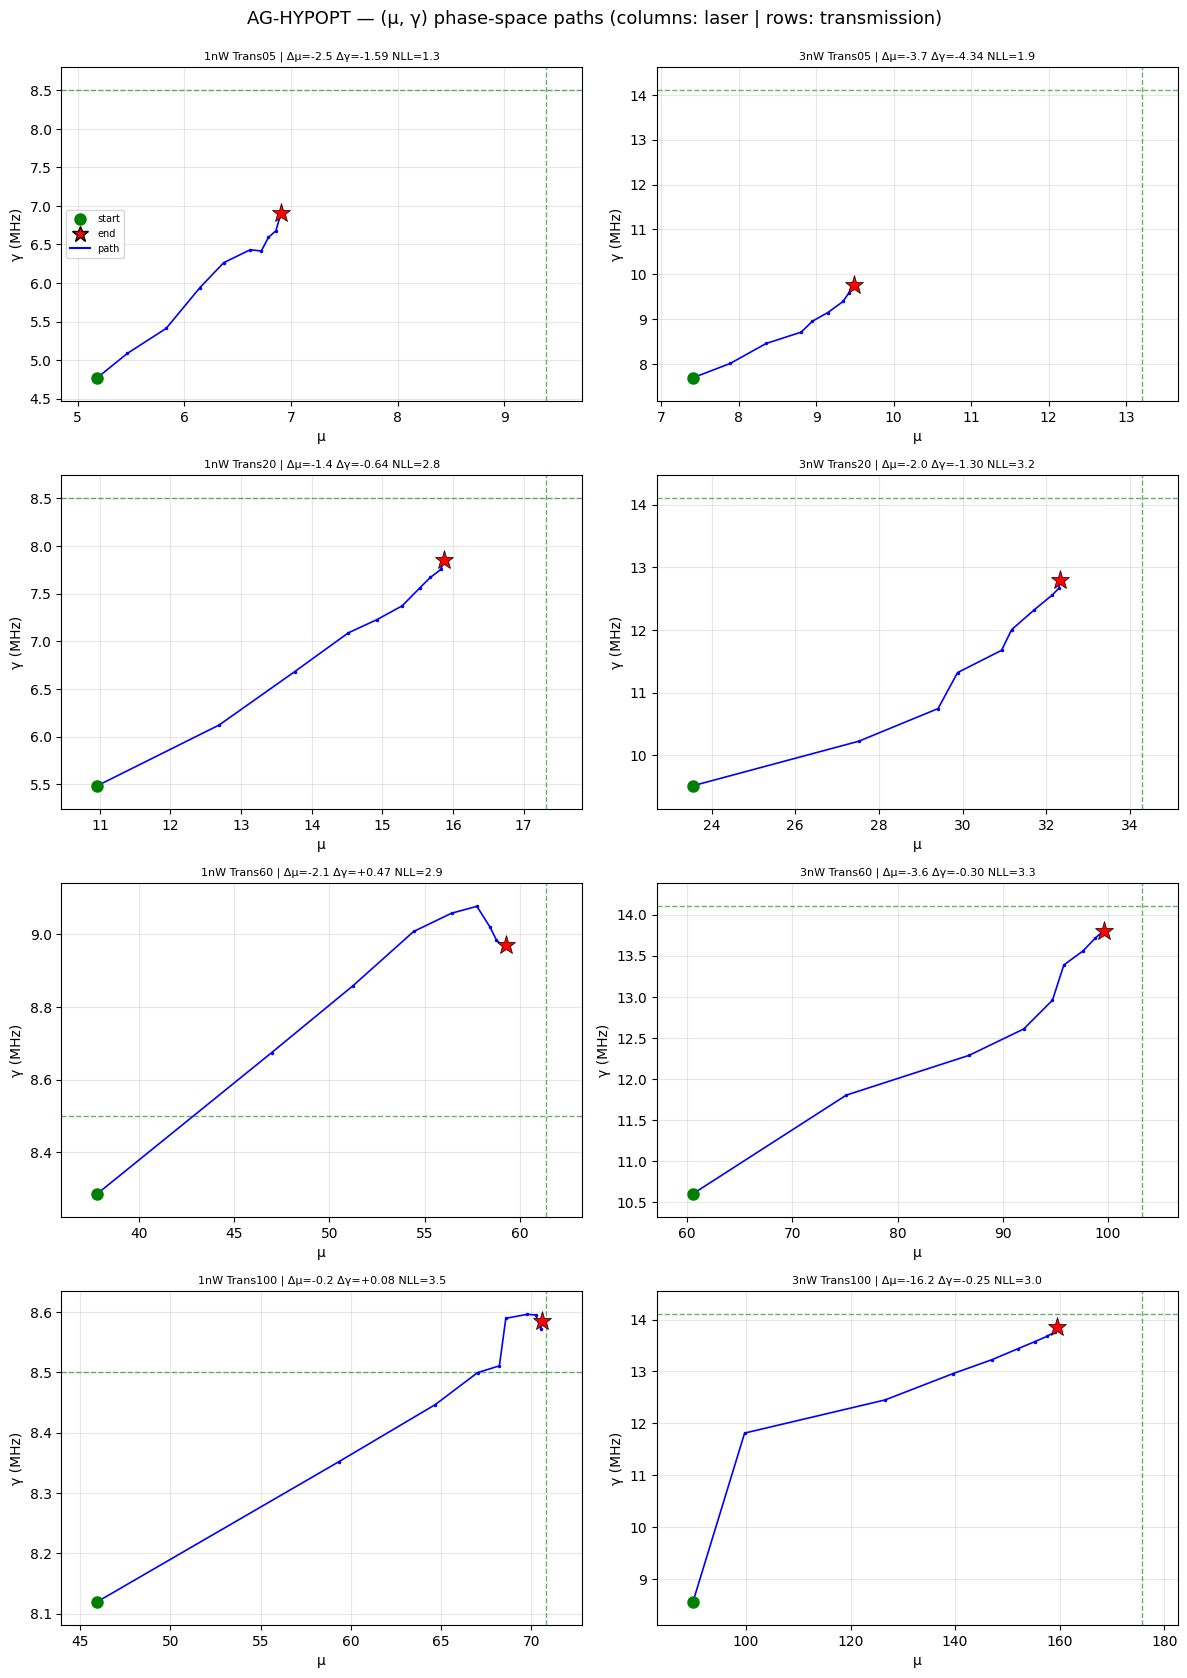

trial finished in 7.0 min
objective = 0.0199 ± 0.0080
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.91   -26.5 |     8.50    6.91   -18.7
1nW Trans20    17.32   15.87    -8.3 |     8.50    7.86    -7.6
1nW Trans60    61.37   59.29    -3.4 |     8.50    8.97    +5.5
1nW Trans100   70.82   70.61    -0.3 |     8.50    8.58    +1.0
3nW Trans05    13.20    9.49   -28.1 |    14.10    9.76   -30.8
3nW Trans20    34.28   32.33    -5.7 |    14.10   12.80    -9.2
3nW Trans60   103.20   99.65    -3.4 |    14.10   13.80    -2.2
3nW Trans100  175.71  159.51    -9.2 |    14.10   13.85    -1.8

μ: RMSE 6.177 (rel 14.6%, bias -3.954) | γ: RMSE 1.726 (rel 13.6%, bias -0.983)


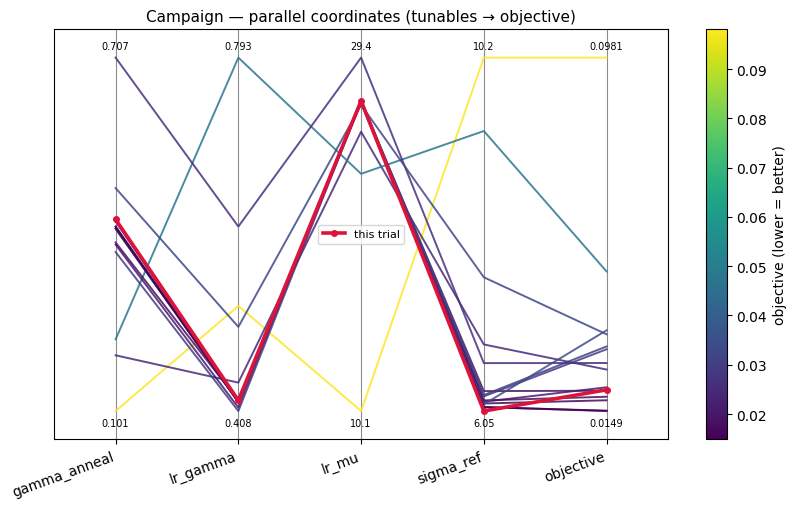

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 15 (sigma_ref 6.047, lr_mu 27.04, lr_gamma 0.419, gamma_anneal 0.430) pushed sigma_ref just below the 6.09 edge of trials 12/14. It ran 7.0 min and scored 0.0199 +/- 0.0080: mu 14.6% (the floor, so the mu side is unaffected) and gamma 13.6%, between the good (9.5-9.6%) and bad (17-21%) plateau runs. So the sub-6.09 push did not improve on trials 12/14, and the objective again tracks the Trans05 gamma (3nW Trans05 -30.8% here). The low-sigma_ref hypothesis is not confirmed: 6.05, 6.09, 6.13 and 6.28 all give the same mu floor and a gamma set by low-count noise. Trial 14 (0.0149) remains best.

**Summary:** Trial 15 (sigma_ref 6.047, lr_mu 27.04, lr_gamma 0.419, gamma_anneal 0.430) scored 0.0199 +/- 0.0080: pushing sigma_ref below 6.09 gave no gain (mu at the 14.6% floor, gamma 13.6%), so trials 12/14 remain the best plateau points.
**Key insight:** sigma_ref below 6.09 does not improve on trials 12/14 (6.09); the plateau gamma, and hence the objective, are set by the erratic low-count Trans05 scans rather than by sigma_ref in this range.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 15 (sigma_ref 6.047, lr_mu 27.04, lr_gamma 0.419, gamma_anneal 0.430) scored 0.0199 +/- 0.0080: pushing sigma_ref below 6.09 gave no gain (mu at the 14.6% floor, gamma 13.6%), so trials 12/14 remain the best plateau points.'
KEY_INSIGHT = 'sigma_ref below 6.09 does not improve on trials 12/14 (6.09); the plateau gamma, and hence the objective, are set by the erratic low-count Trans05 scans rather than by sigma_ref in this range.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_15 | current best: trial_14


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_16.ipynb. Open it and follow its cells from the top.
